<a href="https://www.kaggle.com/code/satish9603/spatial-statastics?scriptVersionId=268985430" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## **Population Stats**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Load the dataset
df = pd.read_csv('/kaggle/input/population-dataset/population.csv')


In [3]:

cols_with_commas = ['Population', 'Males', 'Females', 'Rural Population', 
                    'Urban Population', 'Area (km*km)', 'Density (1/km*km)', 'Sex Ratio']
for col in cols_with_commas:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '').astype(float)
    # Also ensure the column is numeric even if it was not an object (e.g., integer)
    df[col] = pd.to_numeric(df[col])

In [4]:
def get_stats(series, series1=None):
    stats = {
        'Mean': series.mean(),
        'Median': series.median(),
        'Mode': series.mode().iloc[0] if not series.mode().empty else np.nan,
        'Standard Deviation': series.std(),
        'Variance': series.var(),
        'Minimum': series.min(),
        'Maximum': series.max(),
        'Skewness': series.skew(),
        'Kurtosis': series.kurt()
    }

    if series1 is not None:
        stats['Covariance'] = series1.cov(series2)
    return stats

In [5]:
# --- Calculate statistics for required columns ---
population_stats = get_stats(df['Population'])
sex_ratio_stats = get_stats(df['Sex Ratio'])
literacy_rate_stats = get_stats(df['Literacy Rate (%)'])

# --- Print the Results ---

def print_stats(title, stats):
    print(f"--- {title} ---")
    for key, value in stats.items():
        # Check if value is a number before formatting
        if isinstance(value, (int, float)):
            print(f"{key}: {value:,.2f}")
        else:
            print(f"{key}: {value}")
    print("\n")

print_stats("Population Statistics", population_stats)
print_stats("Sex Ratio Statistics", sex_ratio_stats)
print_stats("Literacy Rate (%) Statistics", literacy_rate_stats)


--- Population Statistics ---
Mean: 34,592,026.83
Median: 16,787,941.00
Mode: 64,473.00
Standard Deviation: 44,455,164.74
Variance: 1,976,261,672,211,359.75
Minimum: 64,473.00
Maximum: 199,812,341.00
Skewness: 1.86
Kurtosis: 4.32


--- Sex Ratio Statistics ---
Mean: 931.23
Median: 946.00
Mode: 931.00
Standard Deviation: 79.88
Variance: 6,381.36
Minimum: 618.00
Maximum: 1,084.00
Skewness: -1.86
Kurtosis: 6.37


--- Literacy Rate (%) Statistics ---
Mean: 77.94
Median: 78.03
Mode: 61.80
Standard Deviation: 8.60
Variance: 73.94
Minimum: 61.80
Maximum: 94.00
Skewness: 0.00
Kurtosis: -0.95




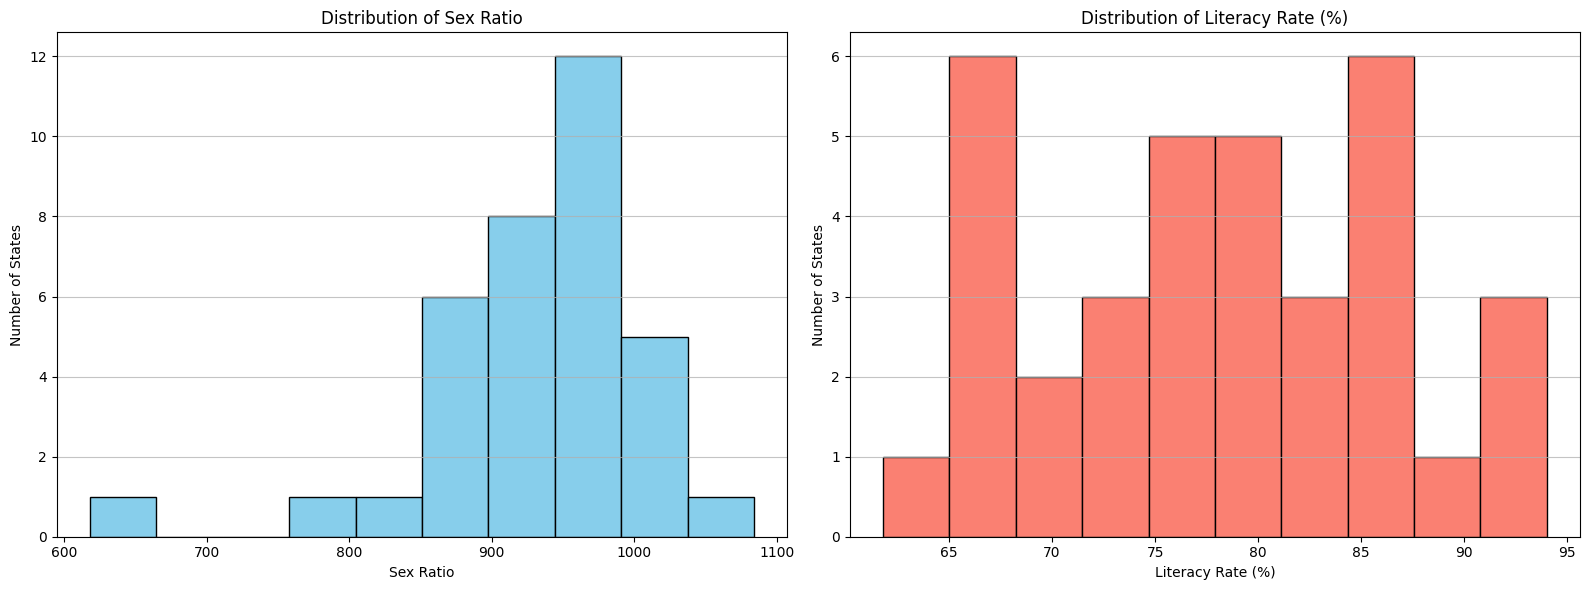

In [6]:
# --- Generate Histograms ---

# Create a figure with two subplots
fig, (FIG1, FIG2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for Sex Ratio
FIG1.hist(df['Sex Ratio'], bins=10, edgecolor='black', color='skyblue')
FIG1.set_title('Distribution of Sex Ratio')
FIG1.set_xlabel('Sex Ratio')
FIG1.set_ylabel('Number of States')
FIG1.grid(axis='y', alpha=0.75)

# Histogram for Literacy Rate
FIG2.hist(df['Literacy Rate (%)'], bins=10, edgecolor='black', color='salmon')
FIG2.set_title('Distribution of Literacy Rate (%)')
FIG2.set_xlabel('Literacy Rate (%)')
FIG2.set_ylabel('Number of States')
FIG2.grid(axis='y', alpha=0.75)

plt.tight_layout()
#plt.savefig('sex_ratio_literacy_distribution.png')

## ****Satellite Database****

In [7]:
#Load the dataset
df_sat = pd.read_excel('/kaggle/input/satellite-database/SATELLITE.xlsx')


In [8]:
#df_sat.replace('NR', pd.NA, inplace=True)

In [9]:
df_sat.columns = df_sat.columns.str.strip()
df_sat['Expected Lifetime (yrs.)'] = pd.to_numeric(df_sat['Expected Lifetime (yrs.)'], errors='coerce')

In [10]:
# Convert 'Date of Launch' to datetime
df_sat['Date of Launch'] = pd.to_datetime(df_sat['Date of Launch'], errors='coerce')

In [11]:
# --- Numerical Analysis ---
print("\n--- Statistical Summary for Expected Lifetime (yrs.) ---")
print(df_sat['Expected Lifetime (yrs.)'].describe())
# --- Categorical Analysis ---
print("\n--- Top 10 Countries of Operator/Owner ---")
country_counts = df_sat['Country of Operator/Owner'].value_counts().nlargest(10)
print(country_counts)
print("\n--- Satellite Users Breakdown ---")
user_counts = df_sat['Users'].value_counts()
print(user_counts)


--- Statistical Summary for Expected Lifetime (yrs.) ---
count    4804.000000
mean        5.510148
std         3.592762
min         0.250000
25%         4.000000
50%         4.000000
75%         5.000000
max        30.000000
Name: Expected Lifetime (yrs.), dtype: float64

--- Top 10 Countries of Operator/Owner ---
Country of Operator/Owner
USA               4511
China              586
United Kingdom     561
Russia             177
Japan               88
Multinational       62
ESA                 62
India               59
Canada              56
Germany             48
Name: count, dtype: int64

--- Satellite Users Breakdown ---
Users
Commercial                        5272
Government                         541
Military                           443
Civil                              154
Government/Commercial               97
Military/Commercial                 81
Military/Government                 56
Government/Civil                    44
Military/Civil                       7
Governmen

In [12]:
print("\n--- Satellite Purpose Breakdown ---")
purpose_counts = df_sat['Purpose'].value_counts()
print(purpose_counts)


--- Satellite Purpose Breakdown ---
Purpose
Communications                                    4812
Earth Observation                                 1142
Technology Development                             366
Navigation/Global Positioning                      141
Space Science                                       98
Technology Demonstration                            42
Earth Science                                       22
Surveillance                                        14
Navigation/Regional Positioning                     13
Unknown                                             10
Earth Observation/Navigation                         9
Space Observation                                    9
Earth Observation/Technology Development             7
Communications/Maritime Tracking                     5
Communications/Technology Development                5
Earth Observation                                    4
Earth Observation/Communications                     2
Earth/Space Observat

In [13]:
print("\n--- Class of Orbit Breakdown ---")
orbit_class_counts = df_sat['Class of Orbit'].value_counts()
print(orbit_class_counts)


--- Class of Orbit Breakdown ---
Class of Orbit
LEO           5936
GEO            580
MEO            142
Elliptical      59
LEo              1
Name: count, dtype: int64


In [14]:
# --- Time-Based Analysis ---
df_sat['Launch Year'] = df_sat['Date of Launch'].dt.year
launch_counts_by_year = df_sat['Launch Year'].value_counts().sort_index()
print("\n--- Satellite Launches Per Year (Last 15 years) ---")
print(launch_counts_by_year.tail(15))



--- Satellite Launches Per Year (Last 15 years) ---
Launch Year
2008.0      49
2009.0      58
2010.0      66
2011.0      84
2012.0      80
2013.0      95
2014.0     117
2015.0     135
2016.0     111
2017.0     231
2018.0     312
2019.0     281
2020.0    1070
2021.0    1601
2022.0    2119
Name: count, dtype: int64


Text(0, 0.5, 'Country')

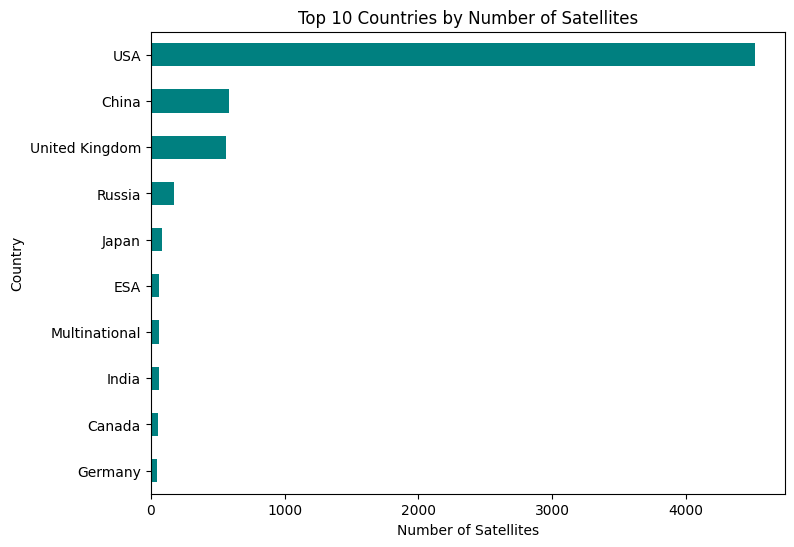

In [15]:
# --- Visualizations ---

# Figure for categorical data
plt.figure(figsize=(18, 6))
# Bar chart for Top 10 Countries
plt.subplot(1, 2, 1)
country_counts.sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Countries by Number of Satellites')
plt.xlabel('Number of Satellites')
plt.ylabel('Country')



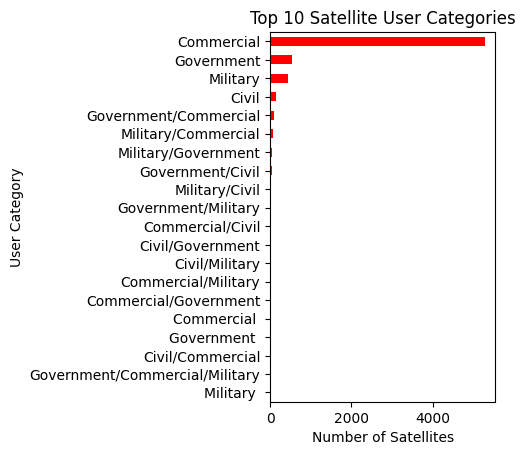

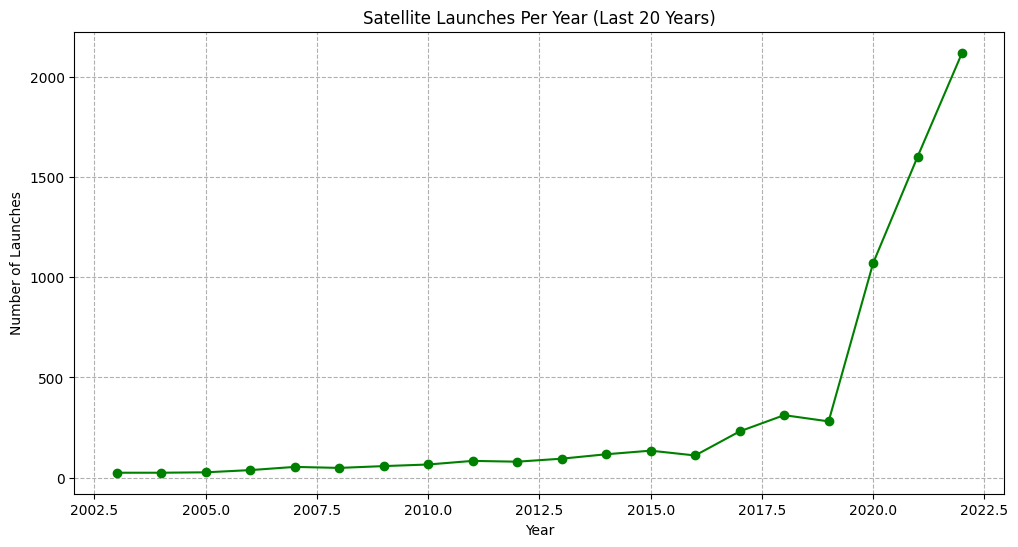

In [16]:
# 2. Horizontal Bar chart for Top 10 Users
plt.subplot(1, 2, 2)
user_counts.sort_values().plot(kind='barh', color='red')
plt.title('Top 10 Satellite User Categories')
plt.xlabel('Number of Satellites')
plt.ylabel('User Category')

#plt.tight_layout()
#plt.savefig('satellite_categorical_analysis_v2.png')


# Figure for time-series data with a changed graph type
plt.figure(figsize=(12, 6))

# 3. Line chart for Satellite Launch Trends
launch_counts_by_year.tail(20).plot(kind='line', marker='o', linestyle='-', color='green')
plt.title('Satellite Launches Per Year (Last 20 Years)')
plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.grid(True, which='both', linestyle='--', linewidth=0.8)
#plt.tight_layout()
#plt.savefig('satellite_launch_trends_v2.png')

## ****Agriculture Dataset****

In [17]:
#Load the dataset
df_agri = pd.read_csv('/kaggle/input/agriculture-dataset/Agriculture Dataset.csv')

print(df_agri.head())


    Crop           State  Cost of Cultivation (`/Hectare) A2+FL  \
0  ARHAR   Uttar Pradesh                                9794.05   
1  ARHAR       Karnataka                               10593.15   
2  ARHAR         Gujarat                               13468.82   
3  ARHAR  Andhra Pradesh                               17051.66   
4  ARHAR     Maharashtra                               17130.55   

   Cost of Cultivation (`/Hectare) C2  Cost of Production (`/Quintal) C2  \
0                            23076.74                            1941.55   
1                            16528.68                            2172.46   
2                            19551.90                            1898.30   
3                            24171.65                            3670.54   
4                            25270.26                            2775.80   

   Yield (Quintal/ Hectare)   
0                       9.83  
1                       7.47  
2                       9.59  
3               

In [18]:
# --- Numerical Analysis ---
print("\n--- Statistical Summary for Numerical Columns ---")
# Use .describe() on the entire dataframe, it will automatically select numeric columns
print(df_agri.describe())


--- Statistical Summary for Numerical Columns ---
       Cost of Cultivation (`/Hectare) A2+FL  \
count                              49.000000   
mean                            20363.537347   
std                             13561.435306   
min                              5483.540000   
25%                             12774.410000   
50%                             17022.000000   
75%                             24731.060000   
max                             66335.060000   

       Cost of Cultivation (`/Hectare) C2  Cost of Production (`/Quintal) C2  \
count                           49.000000                          49.000000   
mean                         31364.666735                        1620.537755   
std                          20095.783569                        1104.990472   
min                           7868.640000                          85.790000   
25%                          19259.840000                         732.620000   
50%                          25909.0

In [19]:
# --- Categorical & Grouped Analysis ---
print("\n--- Crop Distribution ---")
print(df_agri['Crop'].value_counts())

print("\n--- State Distribution ---")
print(df_agri['State'].value_counts())

print("\n--- Average Yield per Crop (Quintal/Hectare) ---")
avg_yield_per_crop = df_agri.groupby('Crop')['Yield (Quintal/ Hectare) '].mean().sort_values(ascending=False)
print(avg_yield_per_crop)

print("\n--- Average Total Cost (Cost_C2) per Crop ---")
avg_cost_per_crop = df_agri.groupby('Crop')['Cost of Cultivation (`/Hectare) C2'].mean().sort_values(ascending=False)
print(avg_cost_per_crop)


--- Crop Distribution ---
Crop
ARHAR                   5
COTTON                  5
GRAM                    5
GROUNDNUT               5
MAIZE                   5
MOONG                   5
PADDY                   5
RAPESEED AND MUSTARD    5
SUGARCANE               5
WHEAT                   4
Name: count, dtype: int64

--- State Distribution ---
State
Andhra Pradesh    8
Uttar Pradesh     7
Maharashtra       6
Karnataka         5
Rajasthan         5
Gujarat           4
Punjab            3
Madhya Pradesh    3
Haryana           2
Tamil Nadu        2
Orissa            2
Bihar             1
West Bengal       1
Name: count, dtype: int64

--- Average Yield per Crop (Quintal/Hectare) ---
Crop
SUGARCANE               790.496
PADDY                    46.296
WHEAT                    33.900
MAIZE                    30.798
COTTON                   18.772
RAPESEED AND MUSTARD     14.320
GRAM                     10.558
GROUNDNUT                10.288
ARHAR                     8.406
MOONG              

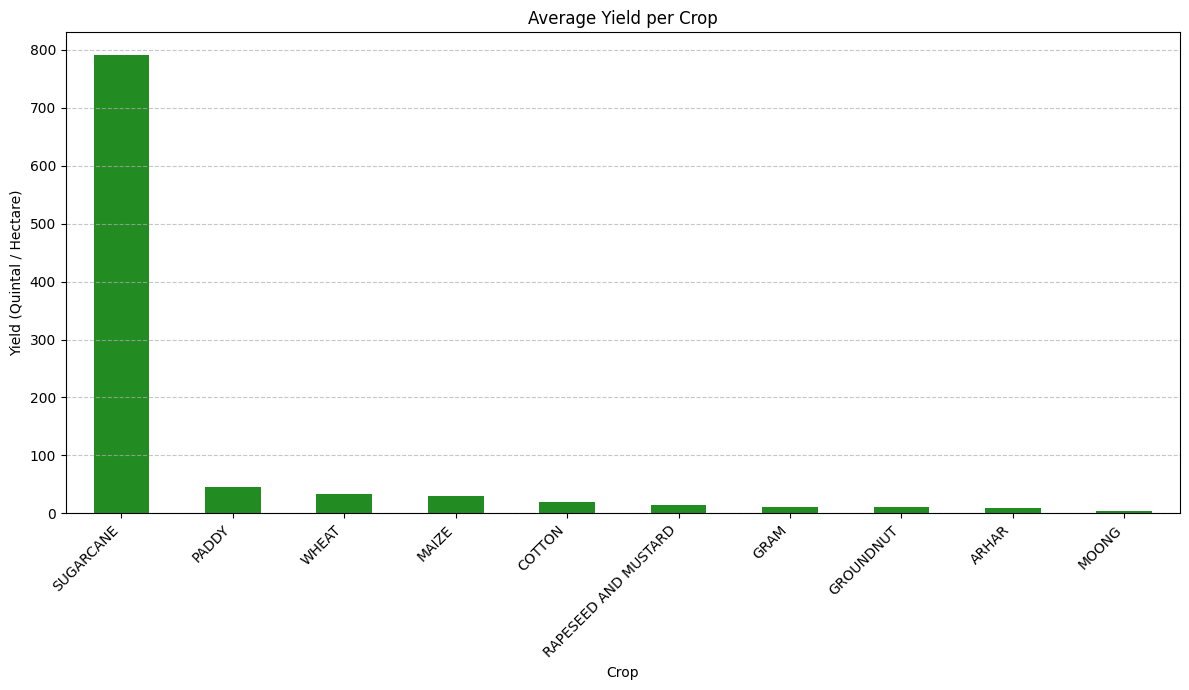

In [20]:
# --- Visualizations ---

# 1. Bar chart for Average Yield per Crop
plt.figure(figsize=(12, 7))
avg_yield_per_crop.plot(kind='bar', color='forestgreen')
plt.title('Average Yield per Crop')
plt.ylabel('Yield (Quintal / Hectare)')
plt.xlabel('Crop')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('average_yield_per_crop.png')

## **Bird Migration Dataset**


In [21]:
#Load the dataset
df_bird = pd.read_csv('/kaggle/input/bird-migration-data/Bird_Migration_Data_.csv')

print(df_bird.head())

  Bird_ID  Species         Region    Habitat Weather_Condition  \
0   B1000  Warbler  South America  Grassland            Stormy   
1   B1001    Stork  North America  Grassland            Stormy   
2   B1002     Hawk  South America   Mountain            Stormy   
3   B1003  Warbler  South America      Urban            Stormy   
4   B1004    Crane         Europe      Urban             Windy   

   Flight_Distance_km  Flight_Duration_hours  Average_Speed_kmph  \
0             1753.79                   49.5               47.82   
1             3263.05                   46.1               48.41   
2             2871.65                   30.2               57.36   
3             2317.38                   58.7               55.38   
4             3077.38                   56.9               53.92   

  Migration_Start_Month Migration_End_Month  
0                   Jan                 Apr  
1                   Apr                 Dec  
2                   May                 Nov  
3         

In [22]:
# --- 2. Numerical Analysis ---
print("--- Numerical Statistics Summary ---\n")
# .describe() provides a great overview, including the median (50%)
numerical_stats = df_bird[['Flight_Distance_km', 'Flight_Duration_hours', 'Average_Speed_kmph']].describe()
print(numerical_stats)
print("\n")


# --- 3. Explicit Mode and Median Calculations (As Requested) ---
print("--- Explicit Mode and Median Calculations ---\n")

# For numerical columns
print("--- Numerical Data ---")
for col in ['Flight_Distance_km', 'Flight_Duration_hours', 'Average_Speed_kmph']:
    median_val = df_bird[col].median()
    mode_val = df_bird[col].mode()[0] # .mode() returns a Series, so we take the first item
    print(f"Column: {col}")
    print(f"  Median: {median_val:.2f}")
    print(f"  Mode:   {mode_val:.2f}\n")

# For categorical columns (Median is not applicable)
print("--- Categorical Data ---")
for col in ['Species', 'Region', 'Weather_Condition']:
    mode_val = df_bird[col].mode()[0]
    print(f"Column: {col}")
    print(f"  Mode:   {mode_val}")
    #print("  (Median is not applicable for categorical data)\n")

--- Numerical Statistics Summary ---

       Flight_Distance_km  Flight_Duration_hours  Average_Speed_kmph
count        10000.000000           10000.000000        10000.000000
mean          2504.036134              49.994020           49.953394
std            499.723298              10.026108            5.085296
min            527.700000              12.600000           30.430000
25%           2169.632500              43.200000           46.530000
50%           2511.150000              50.050000           50.040000
75%           2841.452500              56.800000           53.360000
max           4428.320000              91.000000           68.950000


--- Explicit Mode and Median Calculations ---

--- Numerical Data ---
Column: Flight_Distance_km
  Median: 2511.15
  Mode:   2116.93

Column: Flight_Duration_hours
  Median: 50.05
  Mode:   50.60

Column: Average_Speed_kmph
  Median: 50.04
  Mode:   51.50

--- Categorical Data ---
Column: Species
  Mode:   Hawk
Column: Region
  Mode:   S

In [23]:

print("--- Species Counts ---")
species_counts = df_bird['Species'].value_counts()
print(species_counts)
print("\n")
print("--- Region Counts ---")
region_counts = df_bird['Region'].value_counts()
print(region_counts)
print("\n")

print("--- Weather Condition Counts ---")
weather_counts = df_bird['Weather_Condition'].value_counts()
print(weather_counts)
print("\n")



--- Species Counts ---
Species
Hawk       1464
Stork      1439
Warbler    1429
Goose      1428
Eagle      1426
Swallow    1423
Crane      1391
Name: count, dtype: int64


--- Region Counts ---
Region
South America    1717
North America    1699
Asia             1687
Africa           1669
Australia        1633
Europe           1595
Name: count, dtype: int64


--- Weather Condition Counts ---
Weather_Condition
Foggy     2136
Stormy    2010
Windy     2009
Clear     1925
Rainy     1920
Name: count, dtype: int64




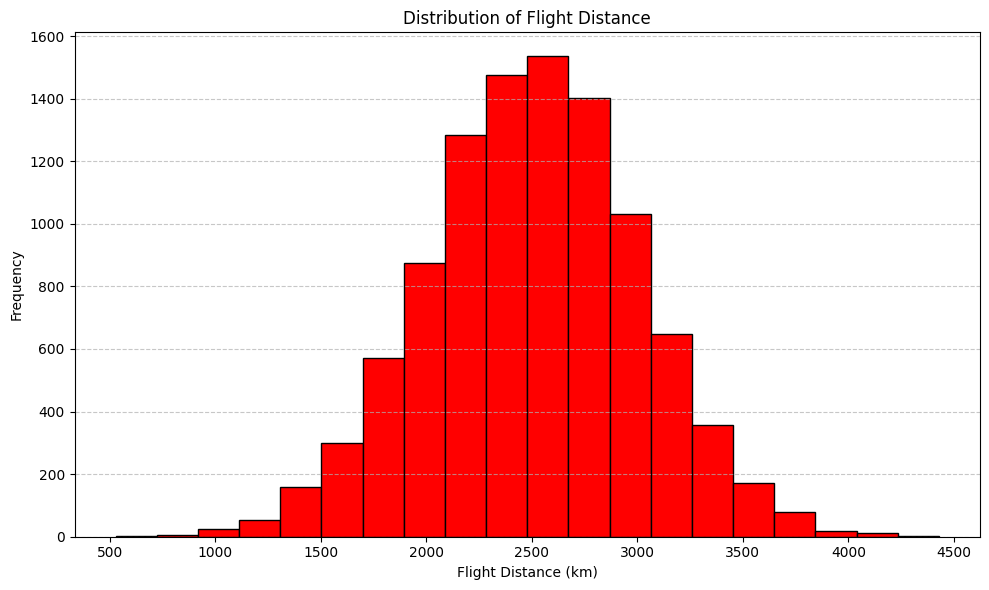

In [24]:


# --- 4. Visualizations ---



# Histogram for Flight Distance
plt.figure(figsize=(10, 6))
plt.hist(df_bird['Flight_Distance_km'], bins=20, color='red', edgecolor='black')
plt.title('Distribution of Flight Distance')
plt.xlabel('Flight Distance (km)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()


## ****Ground Water Dataset****

In [25]:
#Load the dataset
df_grd = pd.read_csv('/kaggle/input/ground-water-data/ground_water_quality_2018_TG.csv')

print(df_grd.head())

   sno  district       mandal      village    lat_gis   long_gis   gwl  \
0    1  ADILABAD     Adilabad     Adilabad  19.668300  78.524700  5.09   
1    2  ADILABAD  Bazarhatnur  Bazarhatnur  19.458888  78.350833  5.10   
2    3  ADILABAD  Gudihatnoor  Gudihatnoor  19.525555  78.512222  4.98   
3    4  ADILABAD      Jainath      Jainath  19.730555  78.640000  5.75   
4    5  ADILABAD      Narnoor      Narnoor  19.495665  78.852654  2.15   

              season    pH   E.C  ...    SO4     Na    K  Ca      Mg  \
0  postmonsoon 2018   8.28   745  ...   46.0   49.0  4.0  48  38.896   
1  postmonsoon 2018   8.29   921  ...   68.0   42.0  5.0  56  63.206   
2  postmonsoon 2018   7.69   510  ...   44.0   45.0  2.0  24  38.896   
3  postmonsoon 2018   8.09   422  ...   35.0   27.0  1.0  32  19.448   
4  postmonsoon 2018   8.21  2321  ...  280.0  298.0  5.0  56  92.378   

          T.H       SAR  Classification  RSC  meq  / L  Classification.1  
0  279.934211  1.273328            C2S1      -1

In [26]:
# --- 2. Numerical Analysis ---
print("--- Numerical Statistics Summary ---\n")
# .describe() provides a great overview, including the median (50%)
numerical_stats = df_grd[['pH','E.C', 'TDS', 'CO3', 'HCO3', 'Cl', 'F', 'SO4', 'Na', 'K', 'Ca', 'Mg']].describe()
print(numerical_stats)
print("\n")


--- Numerical Statistics Summary ---

               pH          E.C          TDS         CO3        HCO3  \
count  374.000000   374.000000   374.000000  374.000000  374.000000   
mean     7.893182  1310.601604   838.785027    7.058824  277.676970   
std      0.453799   761.346975   487.262064   18.478645  125.746737   
min      6.600000   212.000000   135.680000    0.000000   30.000000   
25%      7.580000   766.250000   490.400000    0.000000  186.523010   
50%      7.920000  1173.500000   751.040000    0.000000  263.842574   
75%      8.217500  1666.250000  1066.400000    0.000000  353.548878   
max     10.440000  5440.000000  3481.600000  100.000000  970.588963   

                Cl           F         SO4          Na           K  \
count   374.000000  374.000000  374.000000  374.000000  374.000000   
mean    187.005348    1.237570   44.068182  122.495842    7.832005   
std     175.897896    0.824399   54.500824  103.606183   20.979184   
min      10.000000    0.070000    1.000000

In [27]:
# For numerical columns
print("--- Numerical Data ---")
for col in ['pH','E.C', 'TDS', 'CO3', 'HCO3', 'Cl', 'F', 'SO4', 'Na', 'K', 'Ca', 'Mg']:
    median_val = df_grd[col].median()
    mode_val = df_grd[col].mode()[0] # .mode() returns a Series, so we take the first item
    print(f"Column: {col}")
    print(f"  Median: {median_val:.2f}")
    print(f"  Mode:   {mode_val:.2f}\n")

# For categorical columns (Median is not applicable)
print("--- Categorical Data ---")
for col in ['district', 'mandal', 'village','season']:
    mode_val = df_grd[col].mode()[0]
    print(f"Column: {col}")
    print(f"  Mode:   {mode_val}")
    #print("  (Median is not applicable for categorical data)\n")

--- Numerical Data ---
Column: pH
  Median: 7.92
  Mode:   7.98

Column: E.C
  Median: 1173.50
  Mode:   870.00

Column: TDS
  Median: 751.04
  Mode:   556.80

Column: CO3
  Median: 0.00
  Mode:   0.00

Column: HCO3
  Median: 263.84
  Mode:   200.00

Column: Cl
  Median: 140.00
  Mode:   30.00

Column: F
  Median: 1.06
  Mode:   1.04

Column: SO4
  Median: 24.00
  Mode:   18.00

Column: Na
  Median: 96.70
  Mode:   61.00

Column: K
  Median: 3.00
  Mode:   2.00

Column: Ca
  Median: 56.00
  Mode:   56.00

Column: Mg
  Median: 43.76
  Mode:   38.90

--- Categorical Data ---
Column: district
  Mode:   NALGONDA
Column: mandal
  Mode:   Anumula
Column: village
  Mode:   Angadipet
Column: season
  Mode:   postmonsoon 2018 


In [28]:
# --- Grouped Analysis: Average TDS by District ---
print("--- Top 10 Districts by Average TDS (Total Dissolved Solids) ---")
avg_tds_by_district = df_grd.groupby('district')['TDS'].mean().sort_values(ascending=False)
print(avg_tds_by_district.head(10))
print("\n")


--- Top 10 Districts by Average TDS (Total Dissolved Solids) ---
district
JOGULAMBA(GADWAL)    1426.734545
YADADRI              1381.513846
NAGARKURNOOL         1218.293333
WANAPARTHY           1119.725714
NALGONDA             1043.321081
NARAYANPET           1031.168000
RANGAREDDY            891.317895
NIZAMABAD             881.725217
KHAMMAM               855.552000
MAHABUBABAD           837.360000
Name: TDS, dtype: float64




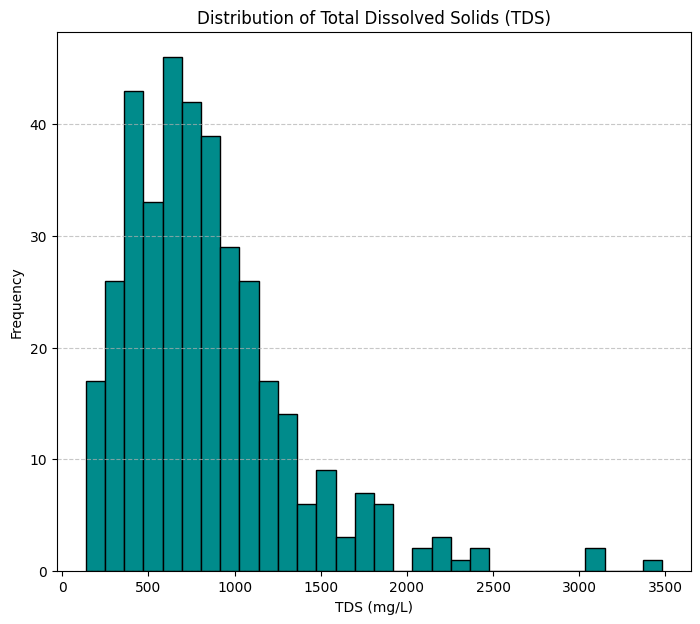

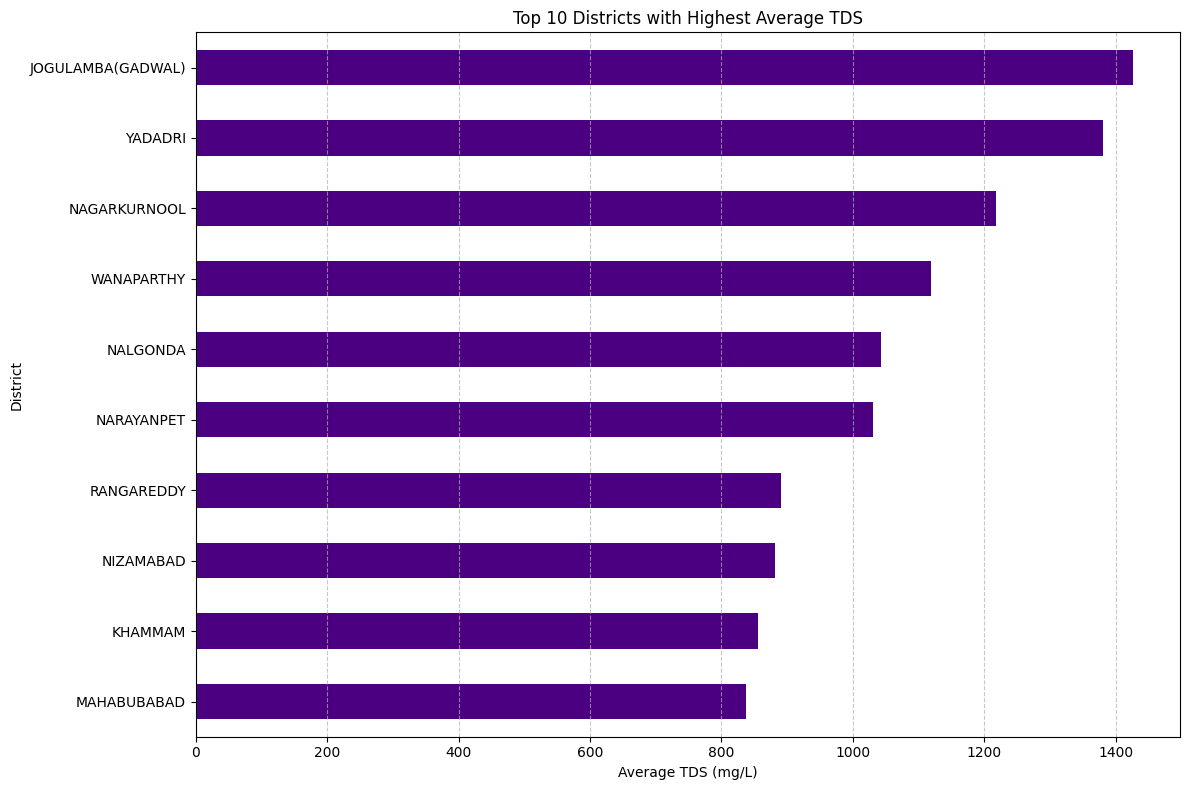

In [29]:
# --- Visualizations ---

# Figure for TDS and Classification
plt.figure(figsize=(18, 7))

# 1. Histogram of TDS Distribution
plt.subplot(1, 2, 1)
plt.hist(df_grd['TDS'], bins=30, color='darkcyan', edgecolor='black')
plt.title('Distribution of Total Dissolved Solids (TDS)')
plt.xlabel('TDS (mg/L)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)





# Bar chart for Top 10 Districts by TDS
plt.figure(figsize=(12, 8))
avg_tds_by_district.head(10).sort_values().plot(kind='barh', color='indigo')
plt.title('Top 10 Districts with Highest Average TDS')
plt.xlabel('Average TDS (mg/L)')
plt.ylabel('District')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('top_districts_by_tds.png')